# ENDF vs ACE comparison via `nuclear_data` canonical classes

Tests the `from_ace()` adapters on `CrossSection`, `AngularDistribution`, and `NuclideInfo`.
Compares Fe-56 data loaded from ENDF (JEFF-4.0) and ACE formats using `ComparisonBuilder` and `PlotBuilder`.

In [1]:
import numpy as np
from kika import read_endf, read_ace
from kika.nuclear_data import CrossSection, AngularDistribution, NuclideInfo
from kika.plotting import PlotBuilder, ComparisonBuilder, AngularDistributionPlotData

endf_file = '/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt'
ace_file = '/share_snc/snc/JuanMonleon/ACE_samples/26056.20c'

endf = read_endf(endf_file)
ace = read_ace(ace_file)
print('ENDF:', endf)
print('ACE ZAID:', ace.header.zaid)

/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:94: UserWarning: Skipping MF sections without parsers: [6, 8, 10, 12, 14, 33]. Only parsing: [1, 2, 3, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


ENDF: ENDF(5 files)
ACE ZAID: 26056


## NuclideInfo comparison

In [2]:
info_endf = NuclideInfo.from_endf(endf.mf[1].mt[451])
info_ace = NuclideInfo.from_ace(ace)

print('ENDF:', info_endf)
print('ACE: ', info_ace)
print()
print('ENDF evaluation_info:', info_endf.evaluation_info)
print('ACE  evaluation_info:', info_ace.evaluation_info)
print()
print('ACE metadata:', info_ace.metadata)

ENDF: NuclideInfo(ZA=26056, AWR=55.4544, T=0.0 K)
ACE:  NuclideInfo(ZA=26056, AWR=55.4544, T=300.0 K)

ENDF evaluation_info: {'laboratory': 'IAEA', 'authors': 'IAEA Consortium', 'eval_date': 'AUG-2018', 'reference': '---INDL/A-3', 'dist_date': 'MATERIAL 2', 'revision_date': '31', 'material_id': '26-Fe- 56'}
ACE  evaluation_info: {'date': '20221201', 'source': None, 'reference': 'ACE file for JENDL-5 n_026-Fe-056'}

ACE metadata: {'source_format': 'ace', 'ace_extension': '.20c', 'ace_matid': 2631, 'ace_format_version': 'legacy'}


## Cross section comparison: MT=2 (elastic)

Uses `CrossSection.from_endf_file()` which reconstructs resonance cross sections from MF2 parameters,
giving pointwise data comparable to ACE (which was processed by NJOY RECONR+BROADR).

In [ ]:
xs_endf_2 = CrossSection.from_endf_file(endf, mt=2)
xs_ace_2 = CrossSection.from_ace(ace, mt=2)

print(xs_endf_2)
print(xs_ace_2)

fig = (
    ComparisonBuilder()
    .set_reference(xs_endf_2.to_plot_data(label='ENDF reconstructed (JEFF-4.0)'))
    .add_comparison(xs_ace_2.to_plot_data(label='ACE'))
    .set_difference_panel(mode='relative', y_lim=(-5, 5))
    .set_labels(
        title='Fe-56 Elastic (MT=2) — Reconstructed ENDF vs ACE',
        x_label='Energy (eV)',
        y_label='Cross section (b)',
    )
    .set_scales(log_x=True, log_y=True)
    .build()
)

In [ ]:
xs_raw_2 = CrossSection.from_endf_file(endf, mt=2, reconstruct=False)

print('Raw MF3:       ', xs_raw_2)
print('Reconstructed: ', xs_endf_2)
print('ACE:           ', xs_ace_2)

fig = (
    ComparisonBuilder()
    .set_reference(xs_ace_2.to_plot_data(label='ACE (NJOY processed)'))
    .add_comparison(xs_raw_2.to_plot_data(label='ENDF raw MF3 (background only)', linestyle='--'))
    .add_comparison(xs_endf_2.to_plot_data(label='ENDF reconstructed (MF2+MF3)', linestyle=':'))
    .set_difference_panel(mode='relative', y_lim=(-100, 100))
    .set_labels(
        title='Fe-56 Elastic (MT=2) — Raw vs Reconstructed vs ACE',
        x_label='Energy (eV)',
        y_label='Cross section (b)',
    )
    .set_scales(log_x=True, log_y=True)
    .build()
)

xs_endf_102 = CrossSection.from_endf_file(endf, mt=102)
xs_ace_102 = CrossSection.from_ace(ace, mt=102)

fig = (
    ComparisonBuilder()
    .set_reference(xs_endf_102.to_plot_data(label='ENDF reconstructed (JEFF-4.0)'))
    .add_comparison(xs_ace_102.to_plot_data(label='ACE'))
    .set_difference_panel(mode='relative', y_lim=(-5, 5))
    .set_labels(
        title='Fe-56 Radiative Capture (MT=102) — Reconstructed ENDF vs ACE',
        x_label='Energy (eV)',
        y_label='Cross section (b)',
    )
    .set_scales(log_x=True, log_y=True)
    .build()
)

## Cross section comparison: MT=102 (radiative capture)

In [ ]:
xs_endf_1 = CrossSection.from_endf_file(endf, mt=1)
xs_ace_1 = CrossSection.from_ace(ace, mt=1)

print('ENDF:', xs_endf_1)
print('ACE: ', xs_ace_1)

fig = (
    ComparisonBuilder()
    .set_reference(xs_endf_1.to_plot_data(label='ENDF reconstructed (JEFF-4.0)'))
    .add_comparison(xs_ace_1.to_plot_data(label='ACE'))
    .set_difference_panel(mode='relative', y_lim=(-5, 5))
    .set_labels(
        title='Fe-56 Total (MT=1) — Reconstructed ENDF vs ACE',
        x_label='Energy (eV)',
        y_label='Cross section (b)',
    )
    .set_scales(log_x=True, log_y=True)
    .build()
)

## Cross section comparison: MT=1 (total) -- ACE composite

ENDF: CrossSection(MT=1, ZA=26056, n_points=15151, E=[1e-05, 1.5e+08] eV)
ACE:  CrossSection(MT=1, ZA=26056, n_points=71183, E=[1e-05, 2e+08] eV)


/home/MONLEON-JUAN/kika/kika/plotting/plot_builder.py:1807: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  self.ax.set_ylim(y_min, y_max)


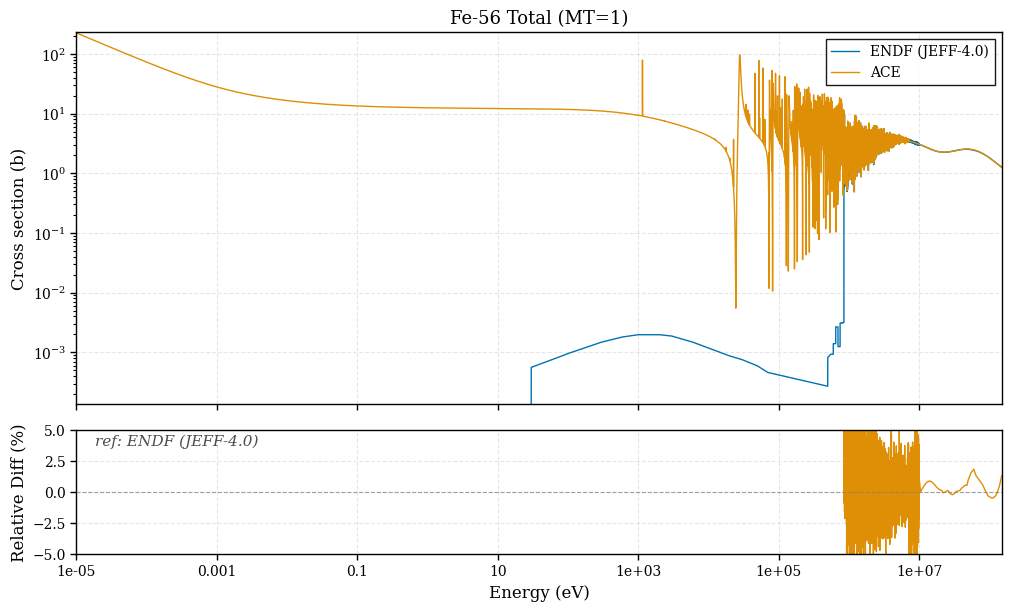

In [5]:
xs_endf_1 = CrossSection.from_endf(endf.mf[3].mt[1])
xs_ace_1 = CrossSection.from_ace(ace, mt=1)

print('ENDF:', xs_endf_1)
print('ACE: ', xs_ace_1)

fig = (
    ComparisonBuilder()
    .set_reference(xs_endf_1.to_plot_data(label='ENDF (JEFF-4.0)'))
    .add_comparison(xs_ace_1.to_plot_data(label='ACE'))
    .set_difference_panel(mode='relative', y_lim=(-5, 5))
    .set_labels(
        title='Fe-56 Total (MT=1)',
        x_label='Energy (eV)',
        y_label='Cross section (b)',
    )
    .set_scales(log_x=True, log_y=True)
    .build()
)

## All available cross sections from ACE

In [6]:
all_xs = CrossSection.all_from_ace(ace)
print(f'{len(all_xs)} reactions extracted:')
for mt, xs in sorted(all_xs.items()):
    print(f'  {xs}')

250 reactions extracted:
  CrossSection(MT=1, ZA=26056, n_points=71183, E=[1e-05, 2e+08] eV)
  CrossSection(MT=2, ZA=26056, n_points=71183, E=[1e-05, 2e+08] eV)
  CrossSection(MT=3, ZA=26056, n_points=71183, E=[1e-05, 2e+08] eV)
  CrossSection(MT=4, ZA=26056, n_points=71183, E=[1e-05, 2e+08] eV)
  CrossSection(MT=5, ZA=26056, n_points=58, E=[2e+07, 2e+08] eV)
  CrossSection(MT=16, ZA=26056, n_points=351, E=[1.14e+07, 2e+08] eV)
  CrossSection(MT=22, ZA=26056, n_points=564, E=[7.75e+06, 2e+08] eV)
  CrossSection(MT=27, ZA=26056, n_points=71183, E=[1e-05, 2e+08] eV)
  CrossSection(MT=28, ZA=26056, n_points=434, E=[1.037e+07, 2e+08] eV)
  CrossSection(MT=51, ZA=26056, n_points=20958, E=[8.62e+05, 2e+08] eV)
  CrossSection(MT=52, ZA=26056, n_points=7805, E=[2.123e+06, 2e+08] eV)
  CrossSection(MT=53, ZA=26056, n_points=5303, E=[2.706e+06, 2e+08] eV)
  CrossSection(MT=54, ZA=26056, n_points=4291, E=[2.995e+06, 2e+08] eV)
  CrossSection(MT=55, ZA=26056, n_points=4257, E=[3.013e+06, 2e+08] eV

## Angular distribution: Legendre coefficients (MT=2)

ENDF stores Legendre coefficients directly; ACE stores tabulated PDFs.
Project the ACE tabulated data to Legendre and compare.

In [7]:
ang_endf = AngularDistribution.from_endf(endf.mf[4].mt[2])
ang_ace = AngularDistribution.from_ace(ace, mt=2)

print('ENDF:', ang_endf)
print('ACE: ', ang_ace)

# Project ACE tabulated PDF to Legendre coefficients
ang_ace.project_to_legendre(max_order=6)
print('ACE after projection: max_order =', ang_ace.max_order)

ENDF: AngularDistribution(MT=2, ZA=26056, repr='mixed', frame='CM', max_L=32, n_energies=3979)
ACE:  AngularDistribution(MT=2, ZA=26056, repr='tabulated', frame='LAB', max_L=0, n_energies=1834)
ACE after projection: max_order = 6


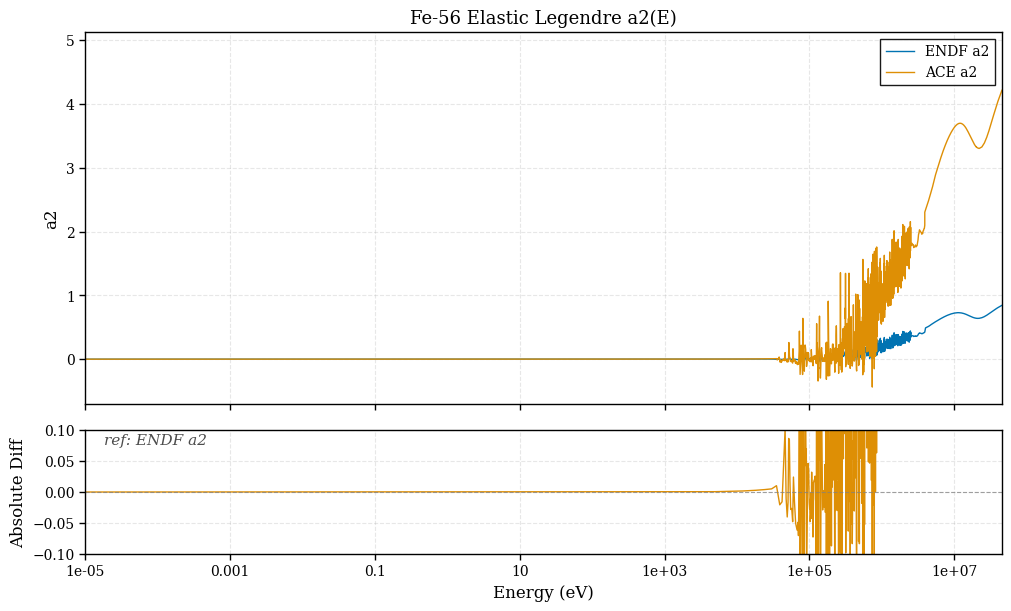

In [8]:
# Compare Legendre coefficients a1(E) and a2(E)
for order in [1, 2]:
    fig = (
        ComparisonBuilder(interpolation='lin-lin')
        .set_reference(ang_endf.to_plot_data(order=order, label=f'ENDF a{order}'))
        .add_comparison(ang_ace.to_plot_data(order=order, label=f'ACE a{order}'))
        .set_difference_panel(mode='absolute', y_lim=(-0.1, 0.1))
        .set_labels(
            title=f'Fe-56 Elastic Legendre a{order}(E)',
            x_label='Energy (eV)',
            y_label=f'a{order}',
        )
        .set_scales(log_x=True)
        .build()
    )

## Angular distribution: PDF comparison at specific energies

Compare ENDF and ACE angular PDFs at 100 keV, 1 MeV, and 10 MeV using `evaluate_pdf()`.

/tmp/ipykernel_15472/1729329506.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


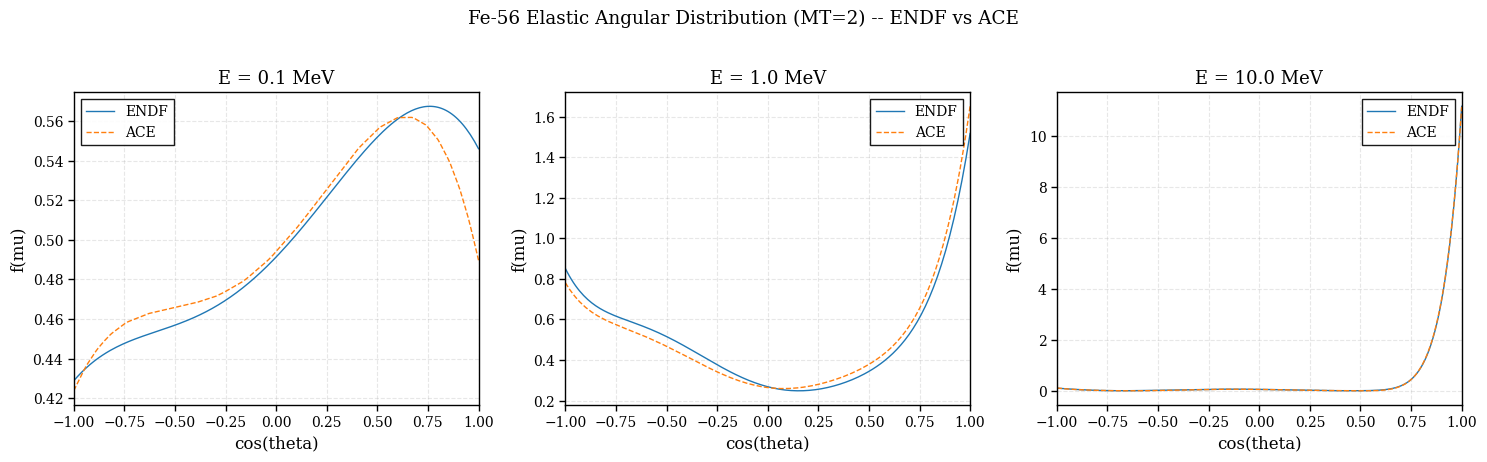

In [9]:
import matplotlib.pyplot as plt

energies_eV = [1e5, 1e6, 1e7]  # 100 keV, 1 MeV, 10 MeV
cosines = np.linspace(-1, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, energy in zip(axes, energies_eV):
    cos_endf, pdf_endf = ang_endf.evaluate_pdf(energy=energy, cosines=cosines)
    cos_ace, pdf_ace = ang_ace.evaluate_pdf(energy=energy, cosines=cosines)

    endf_pd = AngularDistributionPlotData(
        x=cos_endf, y=pdf_endf, energy=energy / 1e6,
        label='ENDF', color='C0',
    )
    ace_pd = AngularDistributionPlotData(
        x=cos_ace, y=pdf_ace, energy=energy / 1e6,
        label='ACE', color='C1', linestyle='--',
    )

    pb = PlotBuilder(ax=ax)
    pb.add_data(endf_pd)
    pb.add_data(ace_pd)
    pb.set_labels(
        title=f'E = {energy/1e6:.1f} MeV',
        x_label='cos(theta)',
        y_label='f(mu)',
    )
    pb.set_legend()
    pb.build()

fig.suptitle('Fe-56 Elastic Angular Distribution (MT=2) -- ENDF vs ACE', y=1.02)
fig.tight_layout()
plt.show()

## PDF comparison with difference using ComparisonBuilder

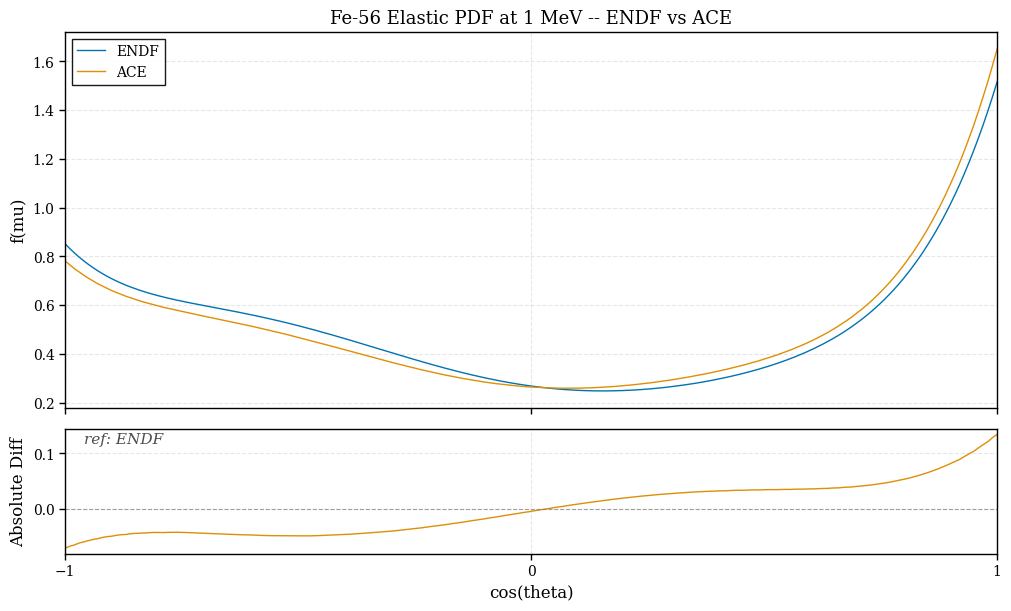

In [10]:
# Detailed comparison at 1 MeV with difference panel
energy = 1e6
cos_endf, pdf_endf = ang_endf.evaluate_pdf(energy=energy, cosines=cosines)
cos_ace, pdf_ace = ang_ace.evaluate_pdf(energy=energy, cosines=cosines)

endf_pd = AngularDistributionPlotData(
    x=cos_endf, y=pdf_endf, energy=energy / 1e6, label='ENDF',
)
ace_pd = AngularDistributionPlotData(
    x=cos_ace, y=pdf_ace, energy=energy / 1e6, label='ACE',
)

fig = (
    ComparisonBuilder()
    .set_reference(endf_pd)
    .add_comparison(ace_pd)
    .set_difference_panel(mode='absolute')
    .set_labels(
        title='Fe-56 Elastic PDF at 1 MeV -- ENDF vs ACE',
        x_label='cos(theta)',
        y_label='f(mu)',
    )
    .build()
)

## All angular distributions from ACE

In [11]:
all_ang = AngularDistribution.all_from_ace(ace)
print(f'{len(all_ang)} angular distributions extracted:')
for mt, ang in sorted(all_ang.items()):
    print(f'  {ang}')

MT=5 uses Kalbach-Mann angular-energy distribution — cannot extract angular distribution alone
MT=16 uses Kalbach-Mann angular-energy distribution — cannot extract angular distribution alone
MT=22 uses Kalbach-Mann angular-energy distribution — cannot extract angular distribution alone
MT=28 uses Kalbach-Mann angular-energy distribution — cannot extract angular distribution alone
MT=91 uses Kalbach-Mann angular-energy distribution — cannot extract angular distribution alone


1 angular distributions extracted:
  AngularDistribution(MT=2, ZA=26056, repr='tabulated', frame='LAB', max_L=0, n_energies=1834)


## Summary assertions

In [12]:
# CrossSection checks
assert xs_ace_2.interpolation == 'linlin'
assert xs_ace_2.energies[0] > 0
assert xs_ace_2.temperature > 200  # should be ~293.6 K
assert 1 in all_xs and 2 in all_xs and 4 in all_xs  # composites present

# AngularDistribution checks
assert ang_ace.frame == 'LAB'
assert ang_ace.energies[0] > 0
assert 1 in ang_ace.coefficients  # populated by project_to_legendre
assert np.allclose(ang_ace.coefficients[0], 1.0)  # a0 = 1 (ENDF convention)

# PDF sanity
cos_out, pdf_out = ang_ace.evaluate_pdf(energy=1e6, cosines=cosines)
assert len(cos_out) == 200
assert np.all(pdf_out >= 0)
assert abs(np.trapezoid(pdf_out, cos_out) - 1.0) < 0.01  # integral ~ 1

# NuclideInfo checks
assert info_ace.nuclide_id == 26056
assert info_ace.atomic_weight_ratio > 50

print('All assertions passed.')

All assertions passed.
